## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf

2024-12-03 12:43:33.405462: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix > len(sequence)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


# Given univariate time series (equal datasteps)
raw_seq = pd.Series([91.57, 91.56, 91.40, 91.39, 91.20, 90.90, 90.99,
                     91.17, 90.98, 91.11, 91.20, 90.92, 90.73, 90.79, 90.86, 90.83,
                     90.80, 90.21, 90.10, 90.10, 89.66, 89.81, 89.40, 89.34, 89.16,
                     88.71, 89.28, 89.36, 89.64, 89.53, 89.32, 89.14, 89.41, 89.53,
                     89.16, 88.98, 88.50, 88.63, 88.62, 88.76, 89.07, 88.47, 88.41,
                     88.57, 88.23, 87.93, 87.88, 88.18, 88.04, 88.18, 88.78, 89.29,
                     89.14, 89.14, 89.42, 89.26, 89.37, 89.51, 89.66, 89.39, 89.02,
                     89.05, 88.97, 88.57, 88.44, 88.52, 87.92, 87.71, 87.52, 87.37,
                     87.27, 87.07, 86.83, 86.88, 87.48, 87.30, 87.87, 87.85, 87.83,
                     87.40, 86.89, 87.38, 87.48, 87.21, 87.02, 87.10, 87.02, 87.07,
                     86.74, 86.35, 86.32, 86.77, 86.77, 86.49, 86.02, 85.52, 85.02,
                     86.02, 85.52, 85.02, 84.42, 85.29])

## Analysis of Time Series


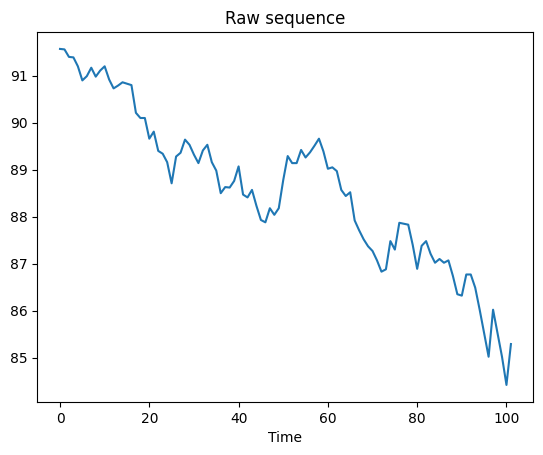

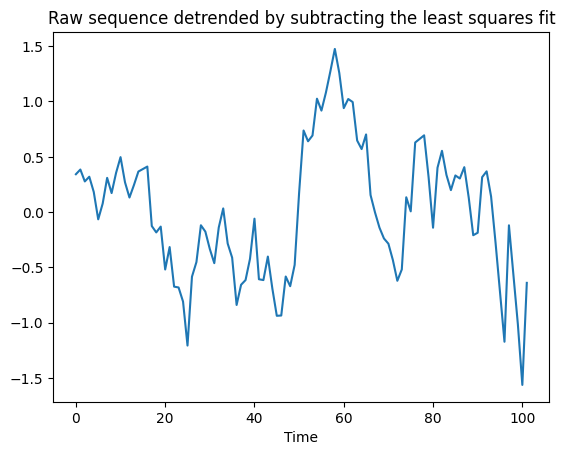

In [3]:
# visualization
raw_seq.plot()
plt.xlabel("Time")
plt.title("Raw sequence")
plt.show()

# Detrending
from scipy import signal
detrended = signal.detrend(raw_seq.values)
plt.plot(detrended)
plt.title('Raw sequence detrended by subtracting the least squares fit')
plt.xlabel("Time")
plt.show()